# EIGSEP Image Fit

Aaron Parsons

In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["OMP_NUM_THREADS"] = "1"

In [2]:
#import multiprocessing as mp
#mp.set_start_method("spawn", force=True)

import numpy as np
import matplotlib.pylab as plt
from matplotlib.image import imread
from scipy.optimize import minimize

from eigsep_terrain.marjum_dem import MarjumDEM as DEM
from eigsep_terrain.img import HorizonImage, PositionSolver, PRM_ORDER
# from eigsep_data.plot import terrain_plot
import healpy
import pymc as pm
import pytensor.tensor as pt
from pytensor.compile.ops import as_op
import os, sys, glob, tqdm
import arviz, corner
import arviz as az
np.random.seed(42)

%matplotlib widget

In [3]:
def terrain_plot(dem, ax=None, xlabel=True, ylabel=True,
             colorbar=True, cmap='terrain', erng_m=None, nrng_m=None,
             decimate=1, **kw):
    E, N, U = dem.get_tile(erng_m=erng_m, nrng_m=nrng_m, mesh=False, decimate=decimate)
    extent = (E[0], E[-1], N[0], N[-1])
    if ax is None:
        ax = plt.gca()
    im = ax.imshow(U, extent=extent, cmap=cmap, origin='lower',
                   interpolation='nearest', **kw)
    if colorbar:
        cb = plt.colorbar(im, ax=ax)
        cb.set_label('Elevation [m]')
    if xlabel:
        ax.set_xlabel('East [m]')
    if ylabel:
        ax.set_ylabel('North [m]')
    return im


In [4]:
CACHE_FILE = 'marjum_dem2.npz'
dem = DEM(cache_file=CACHE_FILE)

In [5]:
dem = DEM(cache_file="marjum_dem2.npz")
E, N = dem.get_en()
print(f"dE = {E[1]-E[0]:.3f}m  dN = {N[1]-N[0]:.3f}m")
print(f"grid size: {len(E)} x {len(N)}")
print(f"extent: E={E[0]:.1f}..{E[-1]:.1f}  N={N[0]:.1f}..{N[-1]:.1f}")

dE = 0.500m  dN = 0.500m
grid size: 10000 x 8000
extent: E=0.0..4999.5  N=0.0..3999.5


In [6]:
new_imgs = glob.glob('/Users/komalkaur/Desktop/eigsep_stuff/eigsep_terrain/2026_imgs/IMG_2*.jpg')
new_imgs = [imread(i) for i in new_imgs]


In [7]:
# # plot new images to find antenna pixel
# fig, ax = plt.subplots()
# im = new_imgs[5]
# ax.imshow(im, origin='upper')


In [8]:
# segment new images
meta = {
    '2209' : {"ant_px": (1606, 2700)},
    '2210' : {"ant_px": (1606, 2700)},
    '2211' : {"ant_px": (1606, 2700)},
    '2213' : {"ant_px": (1606, 2700)},
    '2214' : {"ant_px": (1606, 2700)},
    '2215' : {"ant_px": (1606, 2700)},
    '2216' : {"ant_px": (1606, 2700)},
    '2217' : {"ant_px": (1606, 2700)},
    '2218' : {"ant_px": (1606, 2700)},
    '2219' : {"ant_px": (1606, 2700)},
    '2220' : {"ant_px": (1606, 2700)},
    '2221' : {"ant_px": (1606, 2700)},
    '2222' : {"ant_px": (1606, 2700)},
    '2223' : {"ant_px": (1606, 2700)},
    '2224' : {"ant_px": (1606, 2700)},
    '2225' : {"ant_px": (1606, 2700)},
    '2226' : {"ant_px": (1606, 2700)},
    '2227' : {"ant_px": (1606, 2700)},
    '2228' : {"ant_px": (1606, 2700)},
    '2229' : {"ant_px": (1606, 2700)},
    '2230' : {"ant_px": (1606, 2700)},
    '2231' : {"ant_px": (1606, 2700)},
    '2232' : {"ant_px": (1606, 2700)},
    '2233' : {"ant_px": (1606, 2700)},
    '2234' : {"ant_px": (1606, 2700)},
    '2235' : {"ant_px": (1606, 2700)},
    '2236' : {"ant_px": (1606, 2700)},
    '2237' : {"ant_px": (1606, 2700)},
    '2238' : {"ant_px": (1606, 2700)},
    '2239' : {"ant_px": (1606, 2700)},
    '2241' : {"ant_px": (1606, 2700)},
    '2242' : {"ant_px": (1606, 2700)},
    '2243' : {"ant_px": (1606, 2700)},
    '2245' : {"ant_px": (1606, 2700)}
}
BOX_SIZE = 0.3  # m
#PX_ERR = 2
PX_ERR = 20

files = sorted(glob.glob('/Users/komalkaur/Desktop/eigsep_stuff/eigsep_terrain/2026_imgs/*.jpg'))
print(files)



['/Users/komalkaur/Desktop/eigsep_stuff/eigsep_terrain/2026_imgs/IMG_2209.jpg', '/Users/komalkaur/Desktop/eigsep_stuff/eigsep_terrain/2026_imgs/IMG_2210.jpg', '/Users/komalkaur/Desktop/eigsep_stuff/eigsep_terrain/2026_imgs/IMG_2211.jpg', '/Users/komalkaur/Desktop/eigsep_stuff/eigsep_terrain/2026_imgs/IMG_2213.jpg', '/Users/komalkaur/Desktop/eigsep_stuff/eigsep_terrain/2026_imgs/IMG_2214.jpg', '/Users/komalkaur/Desktop/eigsep_stuff/eigsep_terrain/2026_imgs/IMG_2215.jpg', '/Users/komalkaur/Desktop/eigsep_stuff/eigsep_terrain/2026_imgs/IMG_2216.jpg', '/Users/komalkaur/Desktop/eigsep_stuff/eigsep_terrain/2026_imgs/IMG_2217.jpg', '/Users/komalkaur/Desktop/eigsep_stuff/eigsep_terrain/2026_imgs/IMG_2218.jpg', '/Users/komalkaur/Desktop/eigsep_stuff/eigsep_terrain/2026_imgs/IMG_2219.jpg', '/Users/komalkaur/Desktop/eigsep_stuff/eigsep_terrain/2026_imgs/IMG_2220.jpg', '/Users/komalkaur/Desktop/eigsep_stuff/eigsep_terrain/2026_imgs/IMG_2221.jpg', '/Users/komalkaur/Desktop/eigsep_stuff/eigsep_terra

In [9]:
imgs = [HorizonImage(f, px_dist=30) for f in files]
imgs = [img for img in imgs if img.key in meta]
fit_imgs, static_imgs = imgs, []
_ps = PositionSolver(np.array([0.0, 0, 0]), fit_imgs, static_imgs, 400, dem)

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
/Users/komalkaur/Desktop/eigsep_stuff/.venv/lib/python3.11/site-packages/transformers/image_processing_base.py:417: UserWarning: The following named arguments are not valid for `SegformerImageProcessor.__init__` and were ignored: 'reduce_labels'
  image_processor = cls(**image_processor_dict)
`torch_dtype` is deprecated! Use `dtype` instead!


KeyboardInterrupt: 

In [ ]:
# meta = {
#     '0817': {'ant_px': (2*1366, 2*1221)},
#     '0833': {'ant_px': (1606, 2700)},
#     #'0834': {'ant_px': (1622, 2251)},
# #    'best_prms': ( 1642.45,  1887.80,   1678.94,  1.1787,  1.2417, -0.0310,  2933.66),  #[LOSS= 0.0685]
#     '0860': {'ant_px': (2924, 1945)},
# }
# BOX_SIZE = 0.3  # m
# #PX_ERR = 2
# PX_ERR = 20

# files = sorted(glob.glob('/Users/komalkaur/Desktop/eigsep_stuff/hrzn_mapping/imgs/IMG_08*.jpg'))
# print(files)
# imgs = [HorizonImage(f, px_dist=30) for f in files]
# imgs = [img for img in imgs if img.key in meta]
# fit_imgs, static_imgs = imgs, []
# _ps = PositionSolver(np.array([0.0, 0, 0]), fit_imgs, static_imgs, 400, dem)

['/Users/komalkaur/Desktop/eigsep_stuff/hrzn_mapping/imgs/IMG_0817.jpg', '/Users/komalkaur/Desktop/eigsep_stuff/hrzn_mapping/imgs/IMG_0833.jpg', '/Users/komalkaur/Desktop/eigsep_stuff/hrzn_mapping/imgs/IMG_0860.jpg']


In [6]:
og_best_prms = (
 1734.11,  2069.00,  1760.97,  1.4706,  3.6932, -0.0493,  9830.11,
 1611.31,  1849.00,  1659.78,  1.2053,  1.2414, -0.0244,  5081.08,
 1541.90,  1998.96,  1765.06,  1.5412,  0.6147,  0.1585,  2328.64,
 1651.83,  2024.17,  1781.46
) #this is in u

In [7]:
best_prms_u = ( # u, AFTER MANUAL TUNING
1734.0767, 2068.9027, 1760.9694, 1.4705, 3.6931, -0.0491, 9830.11,
1611.2767, 1848.8707, 1659.7794, 1.2053, 1.2414, -0.0246, 5086.371,
1541.9, 1999.1187, 1765.2354, 1.5412, 0.6155, 0.1585, 2328.64,
1651.83, 2024.17, 1781.46
)

In [8]:
# sols = {
# 'best_prms': (
#  1734.11,  2069.00,  np.log(1.6),  1.4706,  3.6932, -0.0493,  9830.11,
#  1611.31,  1849.00,  np.log(1.6),  1.2053,  1.2414, -0.0244,  5081.08,
#  1541.90,  1998.96,  np.log(1.6),  1.5412,  0.6147,  0.1585,  2328.64,
#  1651.83,  2024.17,  np.log(1781.46-dem.interp_alt(1651.83,  2024.17))
# )
sols = {
'best_prms': ( #logh, AFTER MANUAL TUNING
1734.0767, 2068.9027, np.log(1760.9694 - dem.interp_alt(1734.0767, 2068.9027)), 1.4705, 3.6931, -0.0491, 9830.11,
1611.2767, 1848.8707, np.log(1661 - dem.interp_alt(1611.2767, 1848.8707)), 1.2053, 1.2414, -0.0246, 5086.371,
1541.9, 1999.1187, np.log(1765.2354 - dem.interp_alt(1541.9, 1999.1187)), 1.5412, 0.6155, 0.1585, 2328.64,
1651.83,  2024.17,  np.log(1781.46 - dem.interp_alt(1651.83,  2024.17))
), 
# 'best_prms': (  # this is in logh as it should be according to set_mcmc_prms
#  1734.11,  2069.00,  np.log(1760.97 - dem.interp_alt(1734.11,  2069.00)),  1.4706,  3.6932, -0.0493,  9830.11,
#  1611.31,  1849.00,  np.log(1661 - dem.interp_alt(1611.31,  1849.00)),  1.2053,  1.2414, -0.0244,  5081.08,
#  1541.90,  1998.96,  np.log(1765.06 - dem.interp_alt(1541.90,  1998.96)),  1.5412,  0.6147,  0.1585,  2328.64,
#  1651.83,  2024.17,  np.log(1781.46 - dem.interp_alt(1651.83,  2024.17))
# ),  #[LOGL=-6643.6546]
# 'best_prms': (
#  1734.11,  2069.00,  1760.97,  1.4706,  3.6932, -0.0493,  9830.11,
#  1611.31,  1849.00,  1661,  1.2053,  1.2414, -0.0244,  5081.08,
#  1541.90,  1998.96,  1765.06,  1.5412,  0.6147,  0.1585,  2328.64,
#  1651.83,  2024.17,  1781.46
# ) #this is in u
# old
#'best_prms': (
# 1733.95,  2068.96,  1760.93,  1.4700,  3.6930, -0.0493,  9823.73,
# 1611.54,  1849.07,  1659.77,  1.2049,  1.2416, -0.0235,  5074.40,
# 1541.75,  1998.70,  1765.16,  1.5408,  0.6144,  0.1580,  2326.03,
# 1651.84,  2024.17,  1781.54
#),  #[LOGL=-4949.5580]
#'best_prms': (
# 1733.96,  2068.95,  1760.93,  1.4700,  3.6930, -0.0493,  9823.81,
# 1611.54,  1849.07,  1659.77,  1.2049,  1.2416, -0.0235,  5074.39,
# 1541.76,  1998.69,  1765.16,  1.5408,  0.6144,  0.1580,  2325.98,
# 1651.84,  2024.17,  1781.55
#),  #[LOGL=-4929.2425]
#'best_prms': (
# 1733.96,  2068.95,  1760.93,  1.4700,  3.6930, -0.0493,  9823.93,
# 1611.54,  1849.07,  1659.77,  1.2049,  1.2416, -0.0235,  5074.45,
# 1541.76,  1998.69,  1765.16,  1.5408,  0.6144,  0.1580,  2326.01,
# 1651.84,  2024.17,  1781.54
#),  #[LOGL=-4909.7132]
#'best_prms': (
# 1733.95,  2068.95,  1760.93,  1.4700,  3.6930, -0.0493,  9823.99,
# 1611.55,  1849.06,  1659.77,  1.2049,  1.2416, -0.0235,  5074.48,
# 1541.75,  1998.69,  1765.16,  1.5408,  0.6144,  0.1580,  2326.03,
# 1651.85,  2024.16,  1781.54
#),  #[LOGL=-4908.4298]
}
_ps.set_mcmc_prms(sols['best_prms'])    # expects in logh, actual sampler wants defaults in u. it then will covert before handing to ps object


In [9]:
DEFAULT_PRMS = (
    1734.11, 2069.00, 1760.97, 1.4706, 3.6932, -0.0493, 9830.11,
    1611.31, 1849.00, 1659.78, 1.2053, 1.2414, -0.0244, 5081.08,
    1541.90, 1998.96, 1765.06, 1.5412, 0.6147, 0.1585, 2328.64,
    1651.83, 2024.17, 1781.46,
)

In [10]:
print(np.array(sols['best_prms']))


[ 1.73407670e+03  2.06890270e+03  3.43299962e+00  1.47050000e+00
  3.69310000e+00 -4.91000000e-02  9.83011000e+03  1.61127670e+03
  1.84887070e+03  0.00000000e+00  1.20530000e+00  1.24140000e+00
 -2.46000000e-02  5.08637100e+03  1.54190000e+03  1.99911870e+03
  1.97898565e+00  1.54120000e+00  6.15500000e-01  1.58500000e-01
  2.32864000e+03  1.65183000e+03  2.02417000e+03  4.59975555e+00]


In [11]:
print(_ps.prms_str)

 1734.08,  2068.90,  1760.97,  1.4705,  3.6931, -0.0491,  9830.11,
 1611.28,  1848.87,  1661.00,  1.2053,  1.2414, -0.0246,  5086.37,
 1541.90,  1999.12,  1765.24,  1.5412,  0.6155,  0.1585,  2328.64,
 1651.83,  2024.17,  1781.46


In [12]:
files

['/Users/komalkaur/Desktop/eigsep_stuff/hrzn_mapping/imgs/IMG_0817.jpg',
 '/Users/komalkaur/Desktop/eigsep_stuff/hrzn_mapping/imgs/IMG_0833.jpg',
 '/Users/komalkaur/Desktop/eigsep_stuff/hrzn_mapping/imgs/IMG_0860.jpg']

In [13]:
#dem['platform'] = np.array([1652.80, 2024.20, 1781.60])
# Propagate best parameters back into original objects
dem['platform'] = _ps.ant_pos
for I in _ps.imgs:
    meta[I.key].update({'prms': tuple(I.get_prms())})

for k in meta.keys():
    dem[k] = np.asarray(meta[k])
    
imgs = [HorizonImage(f, meta, px_smooth=150, px_dist=30) for f in files]

# reset img e/n/u to uncorrected DEFAULT_PRMS values before plotting
for cnt, img in enumerate(imgs):
    base = cnt * len(PRM_ORDER)
    img.prms['e'] = DEFAULT_PRMS[base + 0]
    img.prms['n'] = DEFAULT_PRMS[base + 1]
    img.prms['u'] = DEFAULT_PRMS[base + 2]

imgs = [img for img in imgs if img.key in meta]
fit_imgs, static_imgs = imgs, []
n_rays = 4000
ps = PositionSolver(dem['platform'], fit_imgs, static_imgs, n_rays, dem, box_size=BOX_SIZE)
ps.set_mcmc_sigmas()

In [14]:
print(ps.sigmas)
print([img.prms for img in fit_imgs])

[30.0, 30.0, 1.0, np.float64(0.08726646259971647), np.float64(0.08726646259971647), np.float64(0.08726646259971647), np.float32(983.01105), 30.0, 30.0, 1.0, np.float64(0.08726646259971647), np.float64(0.08726646259971647), np.float64(0.08726646259971647), np.float32(508.63712), 30.0, 30.0, 1.0, np.float64(0.08726646259971647), np.float64(0.08726646259971647), np.float64(0.08726646259971647), np.float32(232.864), 30.0, 30.0, 1.0]
[{'e': 1734.11, 'n': 2069.0, 'u': 1760.97, 'th': np.float32(1.4705), 'ph': np.float32(3.6931), 'ti': np.float32(-0.0491), 'f': np.float32(9830.11)}, {'e': 1611.31, 'n': 1849.0, 'u': 1659.78, 'th': np.float32(1.2053), 'ph': np.float32(1.2414), 'ti': np.float32(-0.0246), 'f': np.float32(5086.371)}, {'e': 1541.9, 'n': 1998.96, 'u': 1765.06, 'th': np.float32(1.5412), 'ph': np.float32(0.6155), 'ti': np.float32(0.1585), 'f': np.float32(2328.64)}]


In [ ]:
if True:
    #psky map
    fig, axes = plt.subplots(nrows=3, sharex=True, sharey=True, figsize=(7, 4 * 3))
    r_imgs = {}
    sl = slice(None, None, 2)
    img = imgs[0]
    axes[0].imshow(img.img[sl,sl], origin='lower')
    axes[2].imshow(img.psky[sl,sl], cmap='bwr_r', origin='lower')
    axes[1].imshow(img.img[sl, sl], origin='lower')
    axes[0].imshow(img.psky[sl, sl], origin='lower', cmap='bwr_r', alpha=0.4)
    plt.tight_layout()

In [ ]:
if True:
    fig, axes = plt.subplots(ncols=len(imgs), figsize=(7 * len(imgs), 6))
    if len(imgs) == 1:
        axes = [axes]
    r_imgs = {}
    sl = slice(None, None, 4)
    for cnt, img in enumerate(imgs):
        axes[cnt].imshow(img.img[sl,sl], origin='lower')
        r_imgs[img.key] = img.ray_distance(dem, img.get_rays()[...,sl,sl])
        axes[cnt].imshow(r_imgs[img.key], origin='lower', cmap='gist_ncar', alpha=0.4)
    plt.tight_layout()

In [ ]:
if True:
    fig, axes = plt.subplots(ncols=len(imgs), figsize=(7 * len(imgs), 6))
    if len(imgs) == 1:
        axes = [axes]
    for cnt, img in enumerate(imgs):
        axes[cnt].imshow(img.img, origin='lower')
        axes[cnt].imshow(img.sky_mask, cmap='cool_r', origin='lower', alpha=0.3)
        x, y = img._px_choice
        is_sky = img.sky_mask[x, y]
        axes[cnt].plot(y[is_sky], x[is_sky], 'b,')
        axes[cnt].plot(y[~is_sky], x[~is_sky], 'r,')
        axes[cnt].plot(*img.meta['ant_px'], 'm+')

In [15]:
idata = az.from_netcdf("/Users/komalkaur/Desktop/eigsep_stuff/eigsep_terrain/trace_seed303.nc")  # your no-fit-imgs run

# Posterior mean + std for each sampled param
for name in ["ant_e", "ant_n", "ant_log_h"]:
    arr = idata.posterior[name].values.flatten()
    print(f"{name}: mean={arr.mean():.4f}  std={arr.std():.4f}")

# Convert ant_log_h -> absolute u (height above DEM ground at the fitted e,n)
ant_e = idata.posterior["ant_e"].values.flatten().mean()
ant_n = idata.posterior["ant_n"].values.flatten().mean()
ant_log_h = idata.posterior["ant_log_h"].values.flatten().mean()

u0 = float(dem.interp_alt(ant_e, ant_n))
ant_u = np.exp(ant_log_h) + u0
ant_h = ant_u - u0

print(f"ant_pos (E, N, U) = ({ant_e:.3f}, {ant_n:.3f}, {ant_u:.3f})")
print(f"height above ground = {ant_h:.3f} m")

# If you want the full posterior distribution of U (not just the mean),
# propagate log_h -> u per-sample using the mean e,n (or per-sample e,n if
# you want to fully propagate positional uncertainty too):
log_h_samples = idata.posterior["ant_log_h"].values.flatten()
u_samples = np.exp(log_h_samples) + u0   # using fixed u0 at mean e,n
print(f"U 68% CI: [{np.percentile(u_samples, 16):.2f}, "
      f"{np.percentile(u_samples, 84):.2f}]")

ant_e: mean=1642.9441  std=0.3500
ant_n: mean=2017.2051  std=0.3047
ant_log_h: mean=4.4860  std=0.0028
ant_pos (E, N, U) = (1642.944, 2017.205, 1766.765)
height above ground = 88.765 m
U 68% CI: [1766.55, 1766.95]


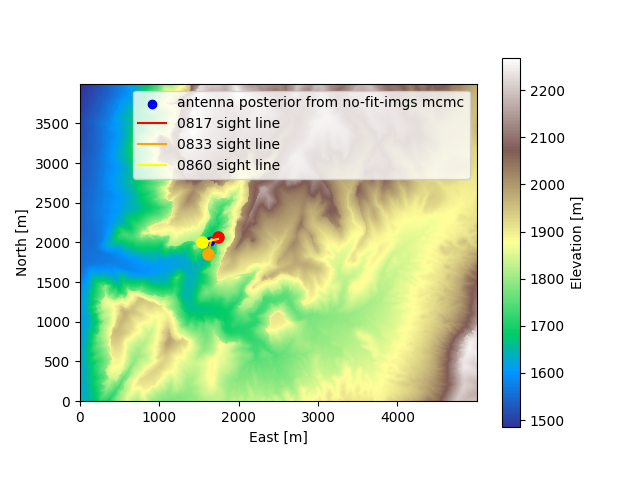

In [16]:
# Ray from each camera through its known antenna pixel 
fig, ax =plt.subplots()
terrain_plot(dem, ax)
L = 200  # m
colors = {'0817': 'red', '0833': 'orange', '0860': 'yellow'}
ax.scatter(ant_e, ant_n, label='antenna posterior from no-fit-imgs mcmc', color='blue')
for img in imgs:
    key = img.key
    if key not in meta:
        continue
    ant_px = meta[key]['ant_px']
    ray = img.get_rays(np.array(ant_px[::-1]))  # 3-vector (E, N, U) bearing

    e0, n0 = img.prms['e'], img.prms['n']
    de, dn = ray[0], ray[1]
    norm = np.hypot(de, dn)
    de, dn = de / norm, dn / norm  # normalize horizontal component only

    ax.plot([e0, e0 + L * de], [n0, n0 + L * dn], '-',
            color=colors.get(key, 'white'), lw=1.5, label=f'{key} sight line')
    ax.plot(e0, n0, 'o', color=colors.get(key, 'white'), ms=8)

ax.legend(loc='upper right')

In [17]:
def lines_intersection_ls(points, dirs):
    """points, dirs: lists of (e, n) — dirs need not be normalized."""
    A = np.zeros((2, 2))
    b = np.zeros(2)
    for p, d in zip(points, dirs):
        d = np.asarray(d, dtype=float)
        d = d / np.linalg.norm(d)
        P = np.eye(2) - np.outer(d, d)  # projector onto perpendicular
        A += P
        b += P @ np.asarray(p, dtype=float)
    return np.linalg.solve(A, b)

pts, dirs = [], []
for img in imgs:
    key = img.key
    if key not in meta:
        continue
    ant_px = meta[key]['ant_px']
    ray = img.get_rays(np.array(ant_px[::-1]))
    e0, n0 = img.prms['e'], img.prms['n']
    de, dn = ray[0], ray[1]
    pts.append((e0, n0))
    dirs.append((de, dn))

e_ls, n_ls = lines_intersection_ls(pts, dirs)
u_ls = float(dem.interp_alt(e_ls, n_ls)) + 1.6  # e.g. antenna/camera height guess
print(f"LS intersection: E={e_ls:.2f}, N={n_ls:.2f}, U~{u_ls:.2f}")
print(f"ant_pos (E, N, U) = ({ant_e:.3f}, {ant_n:.3f}, {ant_u:.3f})")



LS intersection: E=1651.80, N=2024.63, U~1683.60
ant_pos (E, N, U) = (1642.944, 2017.205, 1766.765)


In [ ]:
#nside = 512
##e0, n0, u0 = (1754, 2100, 1747)
#e0, n0, u0 = start_point = np.array((1767, 2095, 1759), dtype=float)
#rays = et.ray.healpix_rays(nside)
##e0, n0, u0 = start_point = np.array(dem['1P'], dtype=float)
##e0, n0, u0 = (0, 0, 1759)

In [ ]:
#healpy.mollview(h.map)
#healpy.mollview(np.log10(ray_trace(start_point)), cmap='plasma')
#healpy.mollview(np.log10(r), cmap='plasma')
#healpy.mollview(np.log10(r2), cmap='plasma')
#healpy.mollview(T[-1], cmap='plasma')
#healpy.mollview((T_sky_full[:, 180]), cmap='plasma')

In [ ]:
if False:
    @as_op(itypes=[pt.dvector], otypes=[pt.dscalar])
    def total_logp_op(theta):
        return np.array(ps.total_logL(np.asarray(theta, dtype=float), verbose=False, eps=1e-2), dtype=float)
        
    with pm.Model() as model:
        prms = ps.get_mcmc_prms()
        theta = pt.stack(prms)
        logL = total_logp_op(theta)
        pm.Potential("lik", logL)
    
        step = pm.DEMetropolisZ(
            S=np.array(ps.sigmas),
            scaling=3e-4,      # much bigger than 1e-3
            tune='scaling',   # let it adapt scale
            tune_interval=50, # adapt more often than default 100
        )
        
        trace = pm.sample(
            draws=4500,
            tune=500,
            chains=4,
            step=step,
            cores=1,
            random_seed=42,
            progressbar=True,
        )
        arviz.to_netcdf(trace, f"total5_trace.nc");
        print(f"Accepted step fraction = {float(trace.sample_stats.accepted.mean()): 4.3f}")

In [ ]:
#arviz.to_netcdf(trace, f"total_trace.nc");
#print(f"Accepted step fraction = {float(trace.sample_stats.accepted.mean()): 4.3f}")

In [ ]:
#trace_files = sorted(glob.glob("*.nc"))
#trace_files = sorted(glob.glob("*.nc"))[:1]
trace_files = sorted(glob.glob("*.nc"))[:2]
print(trace_files)

idata = [arviz.from_netcdf(filename) for filename in trace_files]
trc = arviz.concat(*idata, dim="chain")

In [ ]:
fig, axes = plt.subplots(nrows=len(trc.posterior), sharex=True,figsize=(8, 12))
for i, k in enumerate(trc.posterior.keys()):
    v = np.asarray(trc.posterior[k])
    print(k, np.std(v) / ps.sigmas[i], np.mean(v))
    axes[i].plot(v.T)

In [ ]:
ps.sigmas

In [ ]:
ordered_names = [
  "0817_e","0817_n","0817_u","0817_th","0817_ph","0817_ti","0817_f",
  "0833_e","0833_n","0833_u","0833_th","0833_ph","0833_ti","0833_f",
  "0860_e","0860_n","0860_u","0860_th","0860_ph","0860_ti","0860_f",
  "ant_e","ant_n","ant_u",
]

for t in range(trc.posterior['ant_e'].shape[0]):
    iprms = [trc.posterior[k][t, 0] for k in ordered_names]
    fprms = [trc.posterior[k][t,-1] for k in ordered_names]
    print(t, ps.total_logL(np.asarray(iprms)), ps.total_logL(np.asarray(fprms)))

#logL_total = 0
#for I in imgs:
#    logL_ray = I.horizon_ray_logL(dem, eps=1e-2)
#    print(I.key, logL_ray)
#    logL_ant = I.ant_logL(dem['platform'], BOX_SIZE)
#    print(I.key, logL_ant)
#    logL_total += logL_ray + logL_ant
#print(logL_total)

In [ ]:
vars_to_plot = ["ant_e", "ant_n", "ant_u"]

# Extract posterior samples and stack chains
posterior = trc.posterior[vars_to_plot].stack(sample=("chain", "draw"))

# Shape: (n_samples, n_vars)
samples = np.column_stack(
    [posterior[v].values for v in vars_to_plot]
)

corner.corner(
    samples,
    labels=vars_to_plot,
    show_titles=True
);
#fig = plt.figure(figsize=(8, 8))
#corner.corner(trc, fig=fig);

In [ ]:
trc = arviz.from_netcdf('/Users/komalkaur/Desktop/eigsep_stuff/eigsep_terrain/trace_seed660.nc')

In [ ]:
#e,n,u = dem.latlon_to_enu(39.247907, -113.402715)
#u = dem.interp_alt(e, n)
#print(e, n, u)
fig, ax = plt.subplots()
e0, n0, u0 = dem['platform']
rng = 750
alpha = 0.02
terrain_plot(dem, ax=ax)
#plt.plot([e0], [n0], 's', color='k')
plt.plot(np.asarray(trc.posterior['ant_e']).flatten(), np.asarray(trc.posterior['ant_n']).flatten(), 'k.', alpha=alpha, label=f'antenna')
colors = ['red', 'blue', 'magenta']
for i, img in enumerate(imgs):
    #e, n, u = img.prms['e'], img.prms['n'], img.prms['u']
    #plt.plot([e], [n], '+', color='k', alpha=0.1)
    #ant_ray = img.get_rays(pixels=np.array(img.meta['ant_px'][::-1]))
    #plt.plot([e, e + ant_ray[0] * 220], [n, n + ant_ray[1] * 220], ':', color='k')
    try:
        plt.plot(np.asarray(trc.posterior[f'{img.key}_e']).flatten(), np.asarray(trc.posterior[f'{img.key}_n']).flatten(), '.', alpha=alpha, label=f'img {i}', color=colors[i]);
    except(KeyError):
        plt.plot(np.asarray(trc.posterior['e']).flatten(), np.asarray(trc.posterior['n']).flatten(), '.', alpha=alpha, label=f'img {i}');
leg = plt.legend()
for lh in leg.legend_handles:
    lh.set_alpha(1)

ax.set_title('MCMC steps in the canyon')

In [ ]:
if True:
    #psky map
    fig, ax = plt.subplots()
    r_imgs = {}
    sl = slice(None, None, 2)
    img = imgs[0]
    ax.imshow(img.img[sl,sl], origin='lower')
    im = ax.imshow(img.psky[sl, sl], origin='lower', cmap='bwr_r', alpha=0.4)
    ax.set_title('Probability map')
    cb = plt.colorbar(im, ax=ax)
    cb.set_label('P(sky)')
    plt.tight_layout()

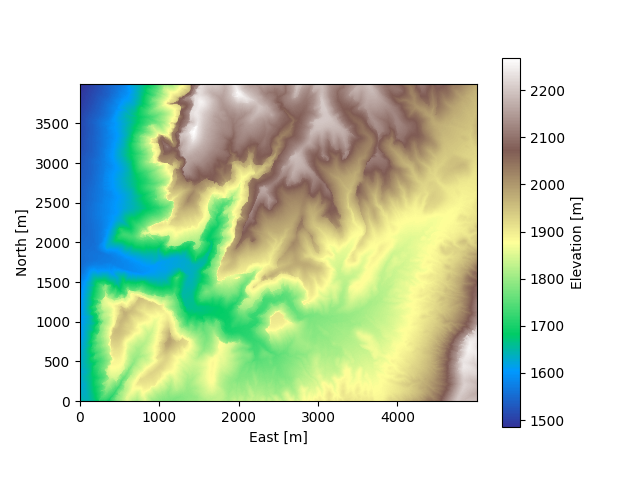

In [24]:
fig, ax = plt.subplots()
terrain_plot(dem, ax)
ax.plot(1672, 2220, ms=8)


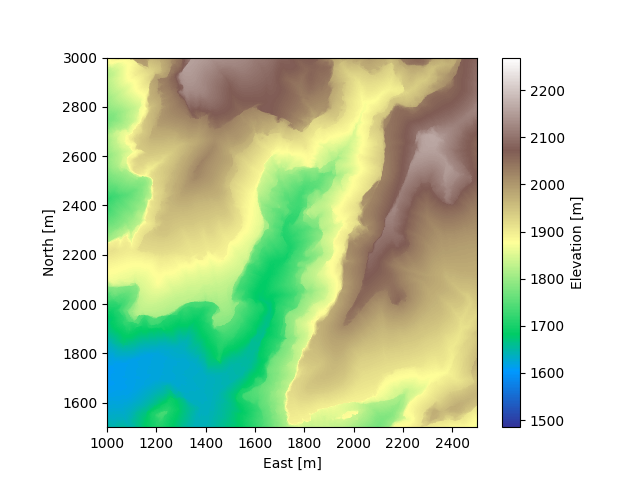

In [ ]:
fig, ax = plt.subplots()
terrain_plot(dem, ax)
ax.set_xlim(1000, 2500)
ax.set_ylim(1500, 3000)
plt.show()


In [18]:
dem.interp_alt(1900,2100)

np.int32(1863)

In [36]:
dem = DEM(cache_file="marjum_dem.npz")
meta = {"2209": {"ant_px": (2146, 232)}}          # edit key/ant_px
img = HorizonImage("/Users/komalkaur/Desktop/eigsep_stuff/eigsep_terrain/2026_imgs/IMG_2210.jpg", 
                   meta, px_smooth=150, px_dist=30)

x0 = np.array([np.float64(1676.9076539897862),
 np.float64(2227.9430247665323),
 np.float64(1782.7324006200038),
 np.float64(1.083975466871556),
 np.float64(0.5356772492502715),
 np.float64(0.22324473629500763),
 np.float64(3038.198479574601)])  # e,n,u,th,ph,ti,f


def neg_logL(x):
    img.set_prms(tuple(x))
    return -img.horizon_ray_logL(dem, n_rays=2000, eps=1e-2, fine_delta=0.25)

res = minimize(neg_logL, x0, method="Nelder-Mead",
                options={"xatol": 1e-3, "fatol": 1e-2, "maxiter": 2000})

print("MAP prms (e,n,u,th,ph,ti,f):", res.x)
print("logL at MAP:", -res.fun)
img.set_prms(tuple(res.x))

MAP prms (e,n,u,th,ph,ti,f): [1.67655275e+03 2.22812414e+03 1.78269779e+03 1.08397665e+00
 5.35535517e-01 2.25303530e-01 3.04173479e+03]
logL at MAP: -1246.57958984375


In [37]:
list(res.x)

[np.float64(1676.552750588285),
 np.float64(2228.124141898507),
 np.float64(1782.697791358827),
 np.float64(1.0839766486576456),
 np.float64(0.5355355172231349),
 np.float64(0.225303530215437),
 np.float64(3041.734793300963)]

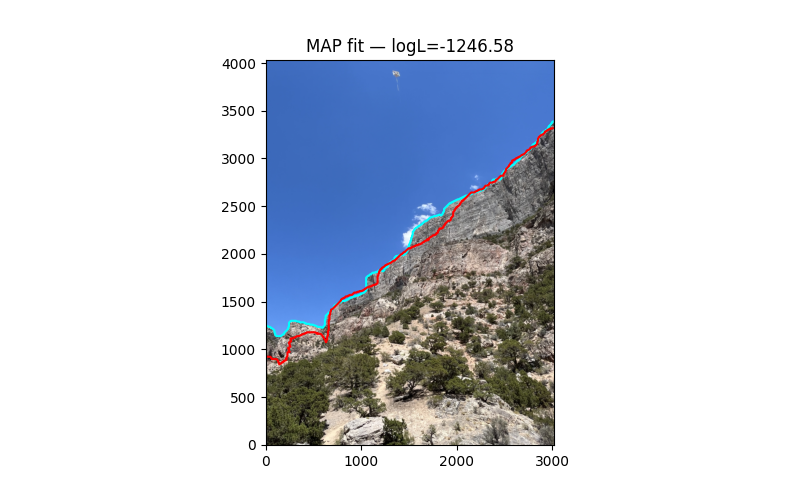

In [38]:
stride = 8
ys = np.arange(0, img.npix_y, stride)
xs = np.arange(0, img.npix_x, stride)
yy, xx = np.meshgrid(ys, xs, indexing="ij")

rays = img.get_rays(pixels=(yy.ravel(), xx.ravel()))
r = img.ray_distance(dem, rays, fine_delta=0.25)
model_sky = np.isnan(r).reshape(yy.shape)

fig, ax = plt.subplots(figsize=(8, 5))
ax.imshow(img.img, origin="lower")
ax.contour(xx, yy, img.sky_mask[np.ix_(ys, xs)].astype(float), levels=[0.5],
           colors="cyan", linewidths=1.5)
ax.contour(xx, yy, model_sky.astype(float), levels=[0.5],
           colors="red", linewidths=1.5)
ax.set_title(f"MAP fit — logL={-res.fun:.2f}")
plt.show()